In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np

# --- Load transcript-level data ---
filtered_df = pd.read_parquet("filtered_df.parquet")

In [125]:
# Starting nucleus df
nuc_df = filtered_df[
    (filtered_df["cell_id"] != "UNASSIGNED") &
    (filtered_df["overlaps_nucleus"] == 1)
].copy()

# Count transcripts per nucleus
nuc_counts = nuc_df.groupby("cell_id").size()

# Compute thresholds
low_thres = np.percentile(nuc_counts, 20)
high_thres = np.percentile(nuc_counts, 80)

print("Transcript count thresholds:", low_thres, high_thres)

# Keep only "confident" nuclei
good_nuc_ids = nuc_counts[(nuc_counts >= low_thres) & (nuc_counts <= high_thres)].index
nuc_df_confident = nuc_df[nuc_df["cell_id"].isin(good_nuc_ids)].copy()

print("Number of confident nuclei:", len(good_nuc_ids))

Transcript count thresholds: 71.0 324.0
Number of confident nuclei: 87371


In [201]:
def compute_npmi_presence_absence(
    df_subset,
    group_key="cell_id",
    min_occurrences_per_context=2
):
    """
    Compute PMI/NPMI using presence/absence of genes at the cell or nucleus level,
    with robustness control by requiring each gene to occur at least N times
    within a context (cell or nucleus) before being considered "present".

    Returns
    -------
    long_df : DataFrame
        Columns:
            gene_i, gene_j, P_i, P_j, P_ij,
            P_i_given_j, P_j_given_i, PMI, NPMI
    """

    # 0. Subset to necessary columns
    df = df_subset[[group_key, "feature_name"]].copy()

    # ----------------------------------------------------------------------
    # Filter by minimum occurrences per context
    # ----------------------------------------------------------------------
    # Count gene occurrences within each cell/nucleus
    counts = (
        df.groupby([group_key, "feature_name"])
        .size()
        .rename("gene_count")
        .reset_index()
    )

    # Keep only those gene occurrences with enough counts
    df_filtered = counts[counts["gene_count"] >= min_occurrences_per_context].copy()

    if df_filtered.empty:
        raise ValueError(
            f"No genes pass min_occurrences_per_context={min_occurrences_per_context}."
        )

    # For presence/absence, set value = 1 for all retained (context, gene) pairs
    df_filtered["value"] = 1

    # ----------------------------------------------------------------------
    # Pivot to contexts × genes matrix (presence/absence)
    # ----------------------------------------------------------------------
    M = df_filtered.pivot_table(
        index=group_key,
        columns="feature_name",
        values="value",
        aggfunc="max",
        fill_value=0
    )

    contexts = M.index.to_numpy()
    genes = M.columns.to_numpy()
    C = M.shape[0]

    # ----------------------------------------------------------------------
    # Probabilities P(i), P(i,j)
    # ----------------------------------------------------------------------
    counts_i = M.sum(axis=0).to_numpy()
    P_i = counts_i / C

    co_matrix = (M.T @ M).to_numpy()
    P_ij = co_matrix / C

    # ----------------------------------------------------------------------
    # Conditional probabilities
    # ----------------------------------------------------------------------
    P_i_col = P_i[:, None]
    P_j_row = P_i[None, :]

    with np.errstate(divide="ignore", invalid="ignore"):
        P_i_given_j = np.where(P_j_row > 0, P_ij / P_j_row, np.nan)
        P_j_given_i = np.where(P_i_col > 0, P_ij / P_i_col, np.nan)

    # ----------------------------------------------------------------------
    # PMI & NPMI
    # ----------------------------------------------------------------------
    PMI = np.full_like(P_ij, np.nan)
    NPMI = np.full_like(P_ij, np.nan)

    denom = P_i_col * P_j_row
    valid = (P_ij > 0) & (denom > 0)

    with np.errstate(divide="ignore", invalid="ignore"):
        PMI[valid] = np.log(P_ij[valid] / denom[valid])
        NPMI[valid] = PMI[valid] / (-np.log(P_ij[valid]))

    # ----------------------------------------------------------------------
    # Convert to long format
    # ----------------------------------------------------------------------
    G = len(genes)
    long_df = pd.DataFrame({
        "gene_i": np.repeat(genes, G),
        "gene_j": np.tile(genes, G),
        "P_i": np.repeat(P_i, G),
        "P_j": np.tile(P_i, G),
        "P_ij": P_ij.ravel(),
        "P_i_given_j": P_i_given_j.ravel(),
        "P_j_given_i": P_j_given_i.ravel(),
        "PMI": PMI.ravel(),
        "NPMI": NPMI.ravel(),
    })

    return long_df



In [202]:
#cell_npmi_long = compute_npmi_presence_absence(cell_df, group_key="cell_id")
nucleus_npmi_long = compute_npmi_presence_absence(nuc_df_confident, group_key="cell_id", min_occurrences_per_context=2)

C:\Users\lyuan13\AppData\Local\Temp\4\ipykernel_39564\323911885.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([group_key, "feature_name"])
C:\Users\lyuan13\AppData\Local\Temp\4\ipykernel_39564\323911885.py:56: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  M = df_filtered.pivot_table(


In [203]:
print("PMI: min =", np.nanmin(nucleus_npmi_long.PMI), "max =", np.nanmax(nucleus_npmi_long.PMI))
print("NPMI: min =", np.nanmin(nucleus_npmi_long.NPMI), "max =", np.nanmax(nucleus_npmi_long.NPMI))

PMI: min = -4.346698268970151 max = 11.377918698802924
NPMI: min = -0.4068124677770301 max = 1.0000000000000009


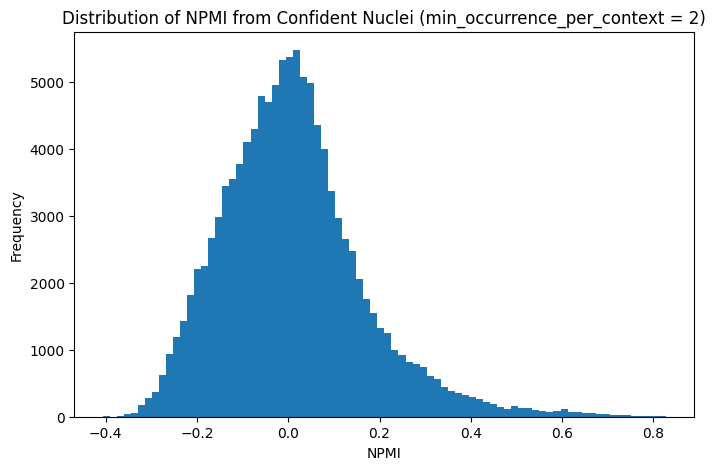

Top 10 highest NPMI gene pairs:
         gene_i  gene_j       P_i       P_j      P_ij  P_i_given_j  \
17185      CD2    TRAC  0.019160  0.029667  0.016779     0.565586   
127780    TRAC     CD2  0.029667  0.019160  0.016779     0.875747   
61471    IL2RB    TRAC  0.025993  0.029667  0.019469     0.656250   
127901    TRAC   IL2RB  0.029667  0.025993  0.019469     0.749009   
18283     CD3G    TRAC  0.016539  0.029667  0.014742     0.496914   
127783    TRAC    CD3G  0.029667  0.016539  0.014742     0.891349   
26564    CNTN2    MYRF  0.236772  0.239668  0.203878     0.850669   
77664     MYRF   CNTN2  0.239668  0.236772  0.203878     0.861072   
127350  TPSAB1   TPSB2  0.002232  0.000996  0.000721     0.724138   
127715   TPSB2  TPSAB1  0.000996  0.002232  0.000721     0.323077   

        P_j_given_i       PMI      NPMI  
17185      0.875747  3.385055  0.828123  
127780     0.565586  3.385055  0.828123  
61471      0.749009  3.228730  0.819694  
127901     0.656250  3.228730  0.819694

In [205]:
# exclude self-pairs
nucleus_npmi_pairs = nucleus_npmi_long[
    nucleus_npmi_long["gene_i"] != nucleus_npmi_long["gene_j"]
].copy()

plt.figure(figsize=(8,5))
plt.hist(nucleus_npmi_pairs["NPMI"].dropna(), bins=80)
plt.xlabel("NPMI")
plt.ylabel("Frequency")
plt.title("Distribution of NPMI from Confident Nuclei (min_occurrence_per_context = 2)")
plt.show()

# Top 10 positive
top10 = nucleus_npmi_pairs.nlargest(10, "NPMI")
print("Top 10 highest NPMI gene pairs:\n", top10)

# Bottom 10
bottom10 = nucleus_npmi_pairs.nsmallest(10, "NPMI")
print("Bottom 10 lowest NPMI gene pairs:\n", bottom10)


In [200]:
nucleus_npmi_long.loc[
    nucleus_npmi_long["gene_i"] == 'KLF2'
].sort_values(by="NPMI", ascending=False).head(60)


,gene_i,gene_j,P_i,P_j,P_ij,P_i_given_j,P_j_given_i,PMI,NPMI
64592,KLF2,KLF2,0.063728,0.063728,0.063728,1.000000,1.000000,2.753127,1.000000
64525,KLF2,ESAM,0.063728,0.033638,0.008664,0.257571,0.135955,1.396666,0.294124
64586,KLF2,ITGA8,0.063728,0.016733,0.004429,0.264706,0.069504,1.423992,0.262754
64714,KLF2,SLIT3,0.063728,0.012682,0.003468,0.273466,0.054418,1.456548,0.257151
64464,KLF2,CD36,0.063728,0.013986,0.003708,0.265139,0.058190,1.425627,0.254705
64448,KLF2,CALCRL,0.063728,0.035160,0.007199,0.204753,0.112967,1.167175,0.236568
64752,KLF2,THSD4,0.063728,0.022742,0.004899,0.215400,0.076868,1.217869,0.228975
64593,KLF2,KLF4,0.063728,0.046411,0.008641,0.186190,0.135596,1.072139,0.225656
64665,KLF2,PECAM1,0.063728,0.153243,0.022673,0.147957,0.355783,0.842296,0.222443
64513,KLF2,DCN,0.063728,0.093349,0.015108,0.161844,0.237069,0.932005,0.222301


In [206]:
#cell_npmi_long.to_csv("cell_npmi_long.csv", index=False)
nucleus_npmi_long.to_csv("nucleus_npmi_long_min_count_2.csv", index=False)

In [130]:
cell_df = filtered_df[filtered_df["cell_id"] != "UNASSIGNED"].copy()

cell_counts = cell_df.groupby("cell_id").size()
good_cell_ids = cell_counts[cell_counts >= 10].index

cell_df_filt = cell_df[cell_df["cell_id"].isin(good_cell_ids)].copy()

# Build presence/absence matrix (cells × genes)
cell_df_filt["value"] = 1
cell_gene = cell_df_filt.pivot_table(index="cell_id",
                                     columns="feature_name",
                                     values="value",
                                     aggfunc=lambda x: 1,
                                     fill_value=0)

cell_ids = cell_gene.index.to_numpy()
M = cell_gene.to_numpy().astype(np.int8)   # shape: (#cells × 366)
genes_cell = cell_gene.columns.to_numpy()


C:\Users\lyuan13\AppData\Local\Temp\4\ipykernel_39564\3857532343.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  cell_gene = cell_df_filt.pivot_table(index="cell_id",


In [131]:
# prepare NPMI matrix
genes_npm = np.union1d(nucleus_npmi_long["gene_i"].unique(),
                       nucleus_npmi_long["gene_j"].unique())
gene_to_idx = {g:i for i,g in enumerate(genes_npm)}
G = len(genes_npm)

npmi_mat = np.zeros((G,G), dtype=float)

for row in nucleus_npmi_long.itertuples(index=False):
    i = gene_to_idx[row.gene_i]
    j = gene_to_idx[row.gene_j]
    npmi_mat[i,j] = row.NPMI
    npmi_mat[j,i] = row.NPMI


In [133]:
# Filter genes ∈ NPMI
mask = np.array([g in gene_to_idx for g in genes_cell])
M = M[:, mask]
genes_cell = genes_cell[mask]
col_idx = np.array([gene_to_idx[g] for g in genes_cell], dtype=np.int32)

In [151]:
#########################
## Conflict Proportion ##
#########################
coherence_scores = []

for row in range(M.shape[0]):
    present_idx = np.where(M[row] == 1)[0]
    gi = col_idx[present_idx]
    k = len(gi)
    if k < 2:
        coherence_scores.append(np.nan)
        continue

    sub = npmi_mat[np.ix_(gi, gi)]
    vals = sub[np.triu_indices_from(sub, k=1)]

    neg_frac = np.mean(vals < 0)
    coherence_scores.append(neg_frac)

In [153]:
len(coherence_scores)

144876

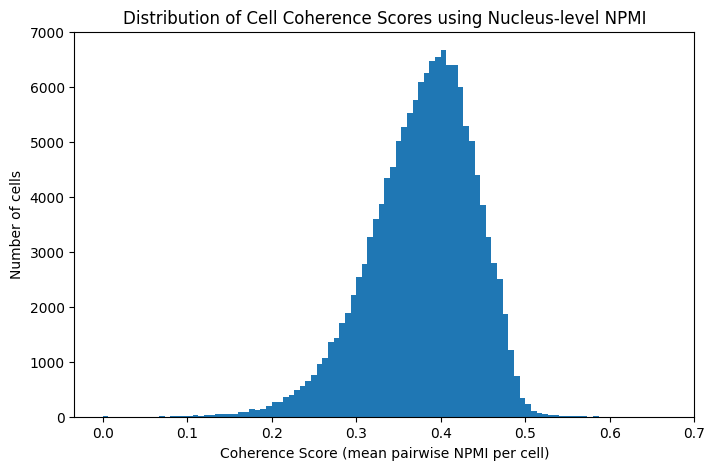

In [154]:
plt.figure(figsize=(8,5))
plt.hist(coherence_scores, bins=100)
plt.xlabel("Coherence Score (mean pairwise NPMI per cell)")
plt.ylabel("Number of cells")
plt.title("Distribution of Cell Coherence Scores using Nucleus-level NPMI")
plt.show()

In [172]:
threshold = np.percentile(coherence_scores, 80) 
suspect_cells = cell_ids[coherence_scores >= threshold]

print("Number of potential merged cells:", len(suspect_cells))

Number of potential merged cells: 28978


In [ ]:
##########
## UMAP ##
##########
import scanpy as sc

# Count matrix
cell_gene_counts = cell_df_filt.pivot_table(
    index="cell_id",
    columns="feature_name",
    values="value",
    aggfunc="count",    
    fill_value=0
)

cell_ids = cell_gene_counts.index.to_numpy()
X_counts = cell_gene_counts.to_numpy(dtype=float)
genes = cell_gene_counts.columns.to_numpy()

adata = sc.AnnData(X_counts)
adata.obs["cell_id"] = cell_ids
adata.var_names = genes


sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=30)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.leiden(adata, resolution=0.6)
sc.tl.umap(adata)

C:\Users\lyuan13\AppData\Local\Temp\4\ipykernel_39564\2870242791.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  cell_gene_counts = cell_df_filt.pivot_table(
c:\Users\lyuan13\.conda\envs\long\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\lyuan13\AppData\Local\Temp\4\ipykernel_39564\2870242791.py:30: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.6)


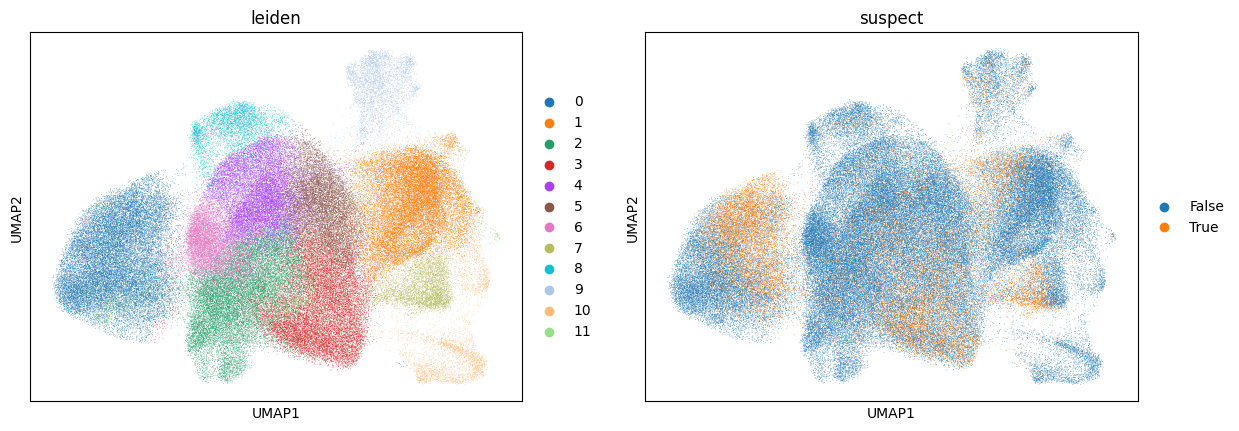

In [173]:
# Add suspect cell indicator
suspect_set = set(suspect_cells)
adata.obs["suspect"] = adata.obs["cell_id"].isin(suspect_set)

sc.pl.umap(adata, color=["leiden", "suspect"])

In [174]:
####################
## Conflict Score ##
####################
coherence_scores = []

for row in range(M.shape[0]):
    present_idx = np.where(M[row] == 1)[0]
    gi = col_idx[present_idx]
    k = len(gi)
    if k < 2:
        coherence_scores.append(np.nan)
        continue

    sub = npmi_mat[np.ix_(gi, gi)]
    neg_vals = sub[np.triu_indices_from(sub, k=1)]
    neg_vals = neg_vals[neg_vals < 0]

    if len(neg_vals) == 0:
        coherence_scores.append(0)   # no conflicts
    else:
        coherence_scores.append(neg_vals.mean())  # more negative = more suspect

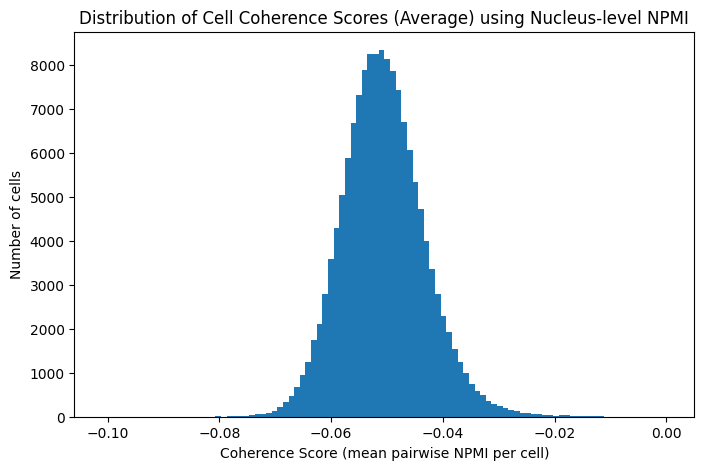

In [175]:
plt.figure(figsize=(8,5))
plt.hist(coherence_scores, bins=100)
plt.xlabel("Coherence Score (mean pairwise NPMI per cell)")
plt.ylabel("Number of cells")
plt.title("Distribution of Cell Coherence Scores (Average) using Nucleus-level NPMI")
plt.show()


In [176]:
threshold = np.percentile(coherence_scores, 10) 
suspect_cells = cell_ids[coherence_scores <= threshold]

print("Number of potential merged cells:", len(suspect_cells))

Number of potential merged cells: 14488


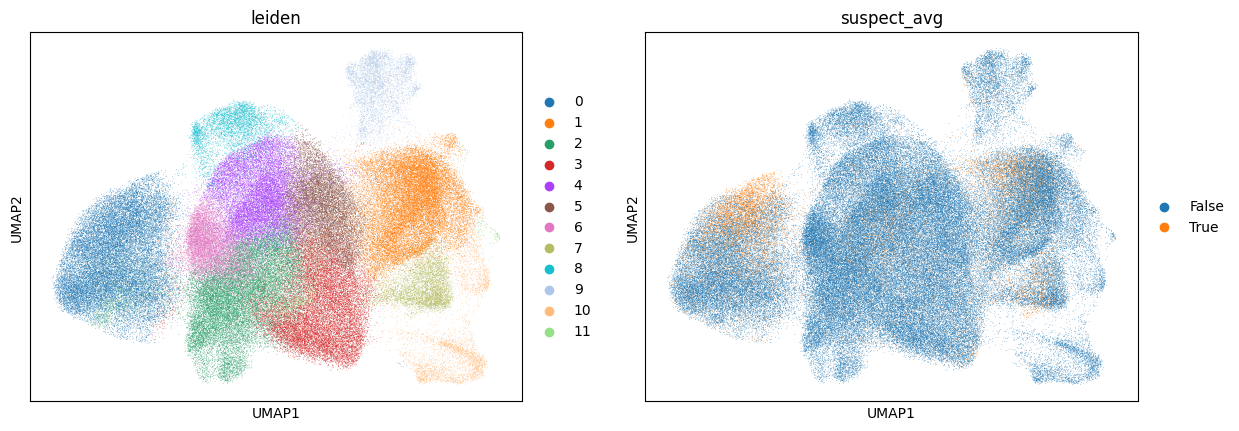

In [177]:
# Add suspect cell indicator
suspect_set = set(suspect_cells)
adata.obs["suspect_avg"] = adata.obs["cell_id"].isin(suspect_set)

sc.pl.umap(adata, color=["leiden", "suspect_avg"])